In [1]:
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = "svg"
import matplotlib.gridspec as gridspec

# Set Up

And verify band structure

In [2]:
from bm_model import *

## Run Calculation

In [3]:
from kubo import *

In [4]:
cutoff = 2

In [5]:
# SET TWIST ANGLE
θ = 2*np.pi/180
mu = 0
T = 77 #K
t_inters = [0,0.11] #eV
eps = 0
strain_dir = 0
displacement = 0
eta = 0.020j

### Plot bands

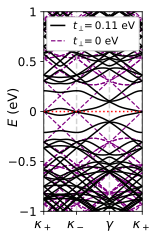

In [6]:
fig = plt.figure(figsize=(2.1,3.2), constrained_layout=True)


#band structures

res = 200

size = 4 * (2*cutoff+1)**2

ks = np.linspace(0,1,res*3)
eigs = np.zeros((res*3,size)) #100 for cutoff = 2, 196 for cutoff = 3
k_points = np.zeros((res*3,2))

K, Kp, G1, G2 = geometry(θ,eps=eps,strain_dir=strain_dir)
G = (G1 - G2)/2 #not (0,0) !
k_points[:res]   = np.outer(K,np.ones(res)).T + np.outer(Kp-K,np.linspace(0,1,res)).T
k_points[res:2*res] = np.outer(Kp,np.ones(res)).T + np.outer(G-Kp,np.linspace(0,1,res)).T
k_points[2*res:] = np.outer(G,np.ones(res)).T+ np.outer(K-G,np.linspace(0,1,res)).T

for j in range(0,3*res,1):
    eigs[j] = np.linalg.eigvalsh(H_valley(k_points[j],θ,cutoff,t_inter=t_inters[1],valley=+1, eps=eps,strain_dir=strain_dir,displacement=displacement))
plt.plot(ks,eigs,lw=1.5,c="k")
plt.plot(ks,eigs[:,0],lw=1.5,c="k",label=r"$t_\perp\!\!=0.11$ eV")

for j in range(0,3*res,1):
    eigs[j] = np.linalg.eigvalsh(H_valley(k_points[j],θ,cutoff,t_inter=t_inters[0],valley=+1, eps=eps,strain_dir=strain_dir,displacement=displacement))
plt.plot(ks,eigs,lw=1.2,ls="dashed",c="purple",zorder=0)
plt.plot(ks,eigs[:,0],lw=1.2,ls="dashed",c="purple",label=r"$t_\perp\!\!=0$ eV",zorder=0)


# plt.title(r"$t\!_\perp\!\!=\!$"+str(int(t_inters[i]*1000))+r"$\,$meV",fontsize=13)
plt.ylim(-1,1)
plt.ylabel(r"  $E$ (eV)",fontsize=13,labelpad=-12)
for j in range(0,4,1):
  plt.axvline(j/3,ls="dashed",c="lightgray",zorder=0)
plt.xticks([0,1/3,2/3,1],[r"$\kappa_+$",r"$\kappa_-$",r"$\gamma$",r"$\kappa_+$"],fontsize=13)
plt.yticks([-1,-0.5,0,0.5,1],["$-1$","$-0.5$","$0$","$0.5$","$1$"],fontsize=12)
plt.xlim(0,1)
plt.axhline(0,c="red",ls="dotted")
plt.legend(handlelength=1.3,fontsize=10.5,loc=9,framealpha=1)
plt.savefig("bands.pdf")

## BM Frame - total, chiral, counterflow

In [7]:
%%time
res = 60 #runtime scales as res^2;
Nw = 201 #number of frequency steps

Ws = np.linspace(0.01,1,Nw)+eta*np.ones(Nw)
s_bm = np.zeros((2, 4,4,Nw),dtype=complex)
s_lab = np.zeros((2, 4,4,Nw),dtype=complex)

# for i in range(2):
#     t_inter = t_inters[i]
#     _, _, G1, G2 = geometry(θ,eps=eps,strain_dir=strain_dir)
#     xs = (np.arange(res) + 0.5) / res - 0.5
#     ys = (np.arange(res) + 0.5) / res - 0.5
#     for x in range(0,res,1): #kx range
#         for y in range(0,res,1): #ky range
#             k = xs[x]*G1 + ys[y]*G2 #parallelogram BZ
#             for valley in [-1,1]: #valley sum
#                 s_bm[i] += kubo_fast(k,θ,mu,T,Ws,cutoff,valley=valley,t_inter=t_inter,eps=eps,strain_dir=strain_dir,displacement=displacement,frame="BM")
#     A_BZ = np.abs(np.linalg.det(np.column_stack([G1,G2]))) #BZ area
#     scale = (A_BZ/(2*np.pi)**2)/res**2 #n_pts
#     s_bm[i] *= scale * 2 #spin degeneracy

CPU times: user 1.29 ms, sys: 137 μs, total: 1.43 ms
Wall time: 191 μs


## Lab Frame - total, chiral, counterflow

In [8]:
# %%time

# for i in range(2):
#     t_inter = t_inters[i]
#     _, _, G1, G2 = geometry(θ,eps=eps,strain_dir=strain_dir)
#     xs = (np.arange(res) + 0.5) / res - 0.5
#     ys = (np.arange(res) + 0.5) / res - 0.5
#     for x in range(0,res,1): #kx range
#         for y in range(0,res,1): #ky range
#             k = xs[x]*G1 + ys[y]*G2 #parallelogram BZ
#             for valley in [-1,1]: #valley sum
#                 s_lab[i] += kubo_fast(k,θ,mu,T,Ws,cutoff,valley=valley,t_inter=t_inter,eps=eps,strain_dir=strain_dir,displacement=displacement,frame="lab")
#     A_BZ = np.abs(np.linalg.det(np.column_stack([G1,G2]))) #BZ area
#     scale = (A_BZ/(2*np.pi)**2)/res**2 #n_pts
#     s_lab[i] *= scale * 2 #spin degeneracy

# plots of mu dependence

In [9]:
# SET TWIST ANGLE
θ = 2*np.pi/180
mus = np.linspace(-0.11,0.11,67)
T = 77 #K
t_inters = [0,0.11] #eV
eps = 0
strain_dir = 0
displacement = 0
eta = 0.020j #0.1 is quite big here

In [10]:
# %%time
# res = 60 #runtime scales as res^2;
# Nw = 201 #number of frequency steps

# Ws = np.linspace(0.01,1,Nw)+eta*np.ones(Nw)
# # s_bm = np.zeros((2,np.shape(mus)[0], 4,4,Nw),dtype=complex)
# s_lab2d = np.zeros((2,np.shape(mus)[0], 4,4,Nw),dtype=complex)

# for i in [1]: #range(2) -- the 0 coupling gives nearly 0 for both (exactly 0 for lab, nearly 0 for BM)
#     t_inter = t_inters[i]
#     _, _, G1, G2 = geometry(θ,eps=eps,strain_dir=strain_dir)
#     xs = (np.arange(res) + 0.5) / res - 0.5
#     ys = (np.arange(res) + 0.5) / res - 0.5
#     for m in range(np.shape(mus)[0]):
#         print(m)
#         mu = mus[m]
#         for x in range(0,res,1): #kx range
#             for y in range(0,res,1): #ky range
#                 k = xs[x]*G1 + ys[y]*G2 #parallelogram BZ
#                 for valley in [-1,1]: #valley sum
#                     # s_bm[i,m] += kubo_fast(k,θ,mu,T,Ws,cutoff,valley=valley,t_inter=t_inter,eps=eps,strain_dir=strain_dir,displacement=displacement,frame="BM")
#                     s_lab2d[i,m] += kubo_fast(k,θ,mu,T,Ws,cutoff,valley=valley,t_inter=t_inter,eps=eps,strain_dir=strain_dir,displacement=displacement,frame="lab")
#         A_BZ = np.abs(np.linalg.det(np.column_stack([G1,G2]))) #BZ area
#         scale = (A_BZ/(2*np.pi)**2)/res**2 #n_pts
#         # s_bm[i,m] *= scale * 2 #spin degeneracy
#         s_lab2d[i,m] *= scale * 2 #spin degeneracy

## Plot

In [11]:
# np.save("s-lab2d.npy",s_lab2d)
# np.save("s-lab.npy",s_lab)
# np.save("s-bm.npy",s_bm)

In [12]:
s_lab2d = np.load("s-lab2d.npy")
s_lab = np.load("s-lab.npy")
s_bm = np.load("s-bm.npy")

/var/folders/jy/26sg472s4m3dk7z6s4trzt640000gn/T/ipykernel_25599/4249682249.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


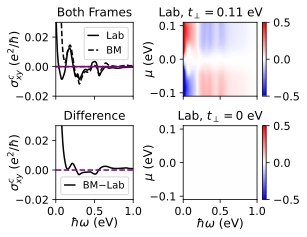

In [13]:
fig = plt.figure(figsize=(4.,3.2))
gs = gridspec.GridSpec(2,2, figure=fig,
                    height_ratios=[1,1],
                    width_ratios=[1,1.4],
                    hspace=0.4, wspace=0.4)

ax = plt.subplot(gs[0,0])
Ws = np.linspace(0,1,201)
sp0lab = reprocess(s_lab[0])
sp1lab = reprocess(s_lab[1])
plt.plot(Ws,np.real(1j*sp0lab[0,3]),c="purple")
plt.plot(Ws,np.real(1j*sp1lab[0,3]),c="k",zorder=0,label="Lab")

sp0bm = reprocess(s_bm[0])
sp1bm = reprocess(s_bm[1])
plt.plot(Ws,np.real(1j*sp0bm[0,3]),c="purple",ls="dashed")
plt.plot(Ws,np.real(1j*sp1bm[0,3]),c="k",zorder=0,ls="dashed",label="BM")
# plt.xlabel(r"$\omega$ (eV)",labelpad=0)
plt.ylabel(r"$\sigma_{xy}^c$ ($e^2/\hbar$)",labelpad=-8,fontsize=12)
plt.xlim(0,1)
plt.ylim(-0.02,0.03)
plt.xticks([0,0.5,1],[],fontsize=11)
plt.yticks(fontsize=11)
plt.title("Both Frames")
plt.legend(handlelength=1)

ax = plt.subplot(gs[1,0])
plt.plot(Ws,np.real(1j*(sp0bm[0,3]-sp0lab[0,3])),c="purple",ls="dashed")
plt.plot(Ws,np.real(1j*(sp1bm[0,3]-sp1lab[0,3])),c="k",zorder=0,label=r"BM$-$Lab")
plt.xlabel(r"$\hbar\omega$ (eV)",labelpad=0,fontsize=12)
plt.ylabel(r"$\sigma_{xy}^c$ ($e^2/\hbar$)",labelpad=-8,fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.xlim(0,1)
plt.ylim(-0.02,0.03)
plt.title(r"Difference")
plt.legend(handlelength=1)



# s_bm_processed = np.zeros(np.shape(s_bm),dtype=complex)
s_lab_processed = np.zeros(np.shape(s_lab2d),dtype=complex)
for i in range(2):
    for m in range(np.shape(mus)[0]):
        # s_bm_processed[i,m] = reprocess(s_bm[i,m])
        s_lab_processed[i,m] = reprocess(s_lab2d[i,m])

ax = plt.subplot(gs[0,1])
plt.imshow(np.real(1j*s_lab_processed[1,:,0,3,:]),vmin=-0.5,vmax=0.5,extent=[0,Ws[-1],mus[0],mus[-1]],aspect=(Ws[0]-Ws[-1])/(mus[0]-mus[-1]),origin="lower",interpolation="nearest",cmap="bwr")
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=11)
# plt.xlabel(r"$\omega$ (eV)",labelpad=1)
plt.ylabel(r"$\mu$ (eV)",labelpad=-5,fontsize=12)
plt.xticks([0,0.5,1],[],fontsize=11)
plt.yticks(fontsize=11)
plt.title(r"Lab, $t_\perp=0.11$ eV     ")

ax = plt.subplot(gs[1,1])
plt.imshow(np.real(1j*s_lab_processed[0,:,0,3,:]),vmin=-0.5,vmax=0.5,extent=[0,Ws[-1],mus[0],mus[-1]],aspect=(Ws[0]-Ws[-1])/(mus[0]-mus[-1]),origin="lower",interpolation="None",cmap="bwr")
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=11)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.xlabel(r"$\hbar\omega$ (eV)",labelpad=1,fontsize=12)
plt.ylabel(r"$\mu$ (eV)",labelpad=-5,fontsize=12)
plt.title(r"Lab, $t_\perp=0$ eV")

plt.tight_layout()
plt.savefig("fig-2.pdf",dpi=600,bbox_inches="tight")
plt.show()
plt.close()